In [40]:
import pandas as pd

In [41]:
url_pop = "https://en.wikipedia.org/wiki/List_of_countries_by_population_%28United_Nations%29"
url_gdp = "https://en.wikipedia.org/wiki/List_of_countries_by_GDP_(PPP)"

In [42]:
data_gdp = pd.read_html(url_gdp)
data_pop = pd.read_html(url_pop)

In [43]:
type(data_gdp)

list

In [44]:
data_gdp_df = data_gdp[1]
data_pop_df = data_pop[0]

In [45]:
data_pop_df

,Country / Area,UN continentalregion[4],UN statisticalsubregion[4],Population(1 July 2022),Population(1 July 2023),Change
0,China[a],Asia,Eastern Asia,1425887337,1425671352,−0.02%
1,India,Asia,Southern Asia,1417173173,1428627663,+0.81%
2,United States,Americas,Northern America,338289857,339996564,+0.50%
3,Indonesia,Asia,South-eastern Asia,275501339,277534123,+0.74%
4,Pakistan,Asia,Southern Asia,235824863,240485658,+1.98%
...,...,...,...,...,...,...
232,Montserrat (United Kingdom),Americas,Caribbean,4390,4387,−0.07%
233,Falkland Islands (United Kingdom),Americas,South America,3780,3791,+0.29%
234,Niue,Oceania,Polynesia,1934,1935,+0.05%
235,Tokelau (New Zealand),Oceania,Polynesia,1871,1893,+1.18%


### First consider data about population

In [46]:
data_pop_df.head(5)

,Country / Area,UN continentalregion[4],UN statisticalsubregion[4],Population(1 July 2022),Population(1 July 2023),Change
0,China[a],Asia,Eastern Asia,1425887337,1425671352,−0.02%
1,India,Asia,Southern Asia,1417173173,1428627663,+0.81%
2,United States,Americas,Northern America,338289857,339996564,+0.50%
3,Indonesia,Asia,South-eastern Asia,275501339,277534123,+0.74%
4,Pakistan,Asia,Southern Asia,235824863,240485658,+1.98%


In [47]:
data_pop_df_clean = data_pop_df[["Country / Area", "Population(1 July 2022)"]]
data_pop_df_clean.columns = ["Country", "Population"]

In [48]:
data_pop_df_clean

,Country,Population
0,China[a],1425887337
1,India,1417173173
2,United States,338289857
3,Indonesia,275501339
4,Pakistan,235824863
...,...,...
232,Montserrat (United Kingdom),4390
233,Falkland Islands (United Kingdom),3780
234,Niue,1934
235,Tokelau (New Zealand),1871


### Consider data about GDP 

In [49]:
new_cols = ["Country", "Region", "IMF_Estimate", "IMF_Year", "WB_Estimate", "WB_Year", "CIA_Estimate", "CIA_Year"]
data_gdp_df.columns = new_cols
data_gdp_df

,Country,Region,IMF_Estimate,IMF_Year,WB_Estimate,WB_Year,CIA_Estimate,CIA_Year
0,World,—,161449514,2022,146714372,2021,127800000,2017
1,China,Asia,30074380,[n 1]2022,27312548,[n 2]2021,23009780,[n 1]2020
2,United States,Americas,25035164,2022,22996100,2021,19846720,2020
3,India,Asia,11665486,2022,10218573,2021,8443360,2020
4,Japan,Asia,6109961,2022,5396819,2021,5224850,2019
...,...,...,...,...,...,...,...,...
224,Tuvalu,Oceania,63,2022,61,2021,50,2020
225,Wallis and Futuna,Oceania,—,—,—,—,60,2004
226,"Saint Helena, Ascension and Tristan da Cunha",Africa,—,—,—,—,31,2009
227,Niue,Oceania,—,—,—,—,10,2003


In [50]:
data_gdp_df_clean = data_gdp_df[["Country", "CIA_Estimate"]]
data_gdp_df_clean

,Country,CIA_Estimate
0,World,127800000
1,China,23009780
2,United States,19846720
3,India,8443360
4,Japan,5224850
...,...,...
224,Tuvalu,50
225,Wallis and Futuna,60
226,"Saint Helena, Ascension and Tristan da Cunha",31
227,Niue,10


In [51]:
total_data = pd.merge(data_gdp_df_clean, data_pop_df_clean, how = "inner", on = "Country")

In [52]:
total_data.shape

(179, 3)

In [53]:
total_data

,Country,CIA_Estimate,Population
0,World,127800000,7975105156
1,United States,19846720,338289857
2,India,8443360,1417173173
3,Japan,5224850,123951692
4,Germany,4238800,83369843
...,...,...,...
174,Marshall Islands,240,41569
175,Palau,320,18055
176,Nauru,150,12668
177,Tuvalu,50,11312


In [54]:
for i, row in total_data.iterrows(): 
    print(row["Country"], row["CIA_Estimate"], row["Population"])

World 127800000 7975105156
United States 19846720 338289857
India 8443360 1417173173
Japan 5224850 123951692
Germany 4238800 83369843
Russia 3875690 144713314
Indonesia 3130470 275501339
Brazil 2989430 215313498
United Kingdom 2797980 67508936
Turkey 2393960 85341241
Italy 2322140 59037474
Mexico 2306320 127504126
South Korea 2187800 51815810
Canada 1742790 38454327
Saudi Arabia 1543240 36408820
Egypt 1223040 110990103
Iran 1044310 88550570
Poland 1223460 39857146
Pakistan 1021130 235824863
Thailand 1206620 71697030
Bangladesh 793490 171186373
Vietnam 798210 98186856
Nigeria 1013530 218541212
Argentina 893310 45510318
Philippines 871560 115559009
Malaysia 855600 33938222
Colombia 683940 51874024
South Africa 680040 59893886
United Arab Emirates 655790 9441129
Switzerland 590710 8740472
Romania 556070 19659267
Belgium 557110 11655930
Singapore 531040 5975689
Sweden 524750 10549347
Ireland 447970 5023109
Algeria 468400 44903225
Austria 463120 8939617
Kazakhstan 475180 19397998
Chile 4458

In [55]:
total_data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 179 entries, 0 to 178
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Country       179 non-null    object
 1   CIA_Estimate  179 non-null    int64 
 2   Population    179 non-null    int64 
dtypes: int64(2), object(1)
memory usage: 5.6+ KB


In [56]:
total_data["CIA_Estimate"] = total_data["CIA_Estimate"].astype(int)
total_data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 179 entries, 0 to 178
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Country       179 non-null    object
 1   CIA_Estimate  179 non-null    int64 
 2   Population    179 non-null    int64 
dtypes: int64(2), object(1)
memory usage: 5.6+ KB


In [57]:
corr_gdp_pop = total_data["CIA_Estimate"].corr(total_data["Population"])

In [58]:
corr_gdp_pop

0.9857271840764646

In [59]:
total_data2 = total_data[1:]

In [60]:
import matplotlib.pyplot as plt 
gdp = total_data2["CIA_Estimate"]
pop = total_data2["Population"]

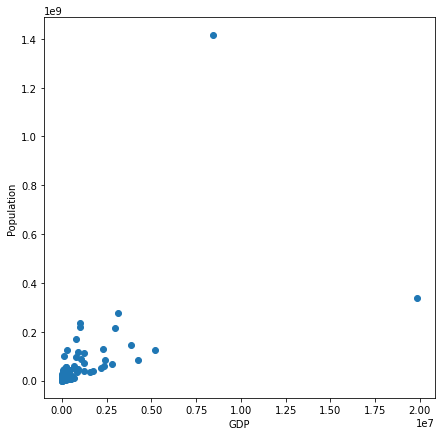

In [61]:
plt.figure(figsize = (7, 7))
plt.scatter(gdp, pop)
plt.xlabel("GDP")
plt.ylabel("Population")
plt.show()